# Gibbs Sampler — Corrected Analysis

## Bug Identified in Prior Version

The original `gibbs_msm` implementation had a **silent but fatal bug**: the
Forward-Filtering Backward-Sampling step was called, but its return value
was never assigned back to `S`:

```python
# BROKEN (original)
ffbs(y, mu, sig2, p_diag)   # result discarded into the void

# FIXED
S = ffbs(y, mu, sig2, p_diag)  # latent states actually update
```

Because `S` was stuck at its initial deterministic guess
(`S = (y >= median(y))`), every parameter draw was conditioned on the
**same two static sub-samples** — returns above vs. below the overall
median. The sampler appeared to converge (trace plots still look fine)
but was sampling from an entirely wrong conditional distribution.

This notebook re-runs the full analysis with the corrected sampler.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, invgamma, beta as beta_dist

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')


In [2]:
sp500_df = pd.read_csv('sp500_data.csv', index_col='Date')
nifty50_df = pd.read_csv('nifty50_data.csv', index_col='Date')
recession_df = pd.read_csv('us_recession.csv', index_col='observation_date')

sp500_df.index   = pd.to_datetime(sp500_df.index,   utc=True).tz_localize(None)
nifty50_df.index = pd.to_datetime(nifty50_df.index, utc=True).tz_localize(None)
recession_df.index = pd.to_datetime(recession_df.index)

sp500_df   = sp500_df.dropna(subset=['Log_Return'])
nifty50_df = nifty50_df.dropna(subset=['Log_Return'])

print(f"S&P 500 observations : {len(sp500_df)}")
print(f"NIFTY 50 observations: {len(nifty50_df)}")


S&P 500 observations : 1110
NIFTY 50 observations: 969


## FFBS + Gibbs Sampler (Corrected)

The only change from the prior version is the assignment `S = ffbs(...)`.
Everything else (priors, full conditionals, burn-in) is identical.


In [3]:
def ffbs(y, mu, sig2, p_diag):
    """Forward-Filtering Backward-Sampling — samples the full state path jointly."""
    T = len(y)
    P_mat = np.array([[p_diag[0], 1 - p_diag[0]],
                      [1 - p_diag[1], p_diag[1]]])

    P_filt = np.zeros((T, 2))
    P_filt[0] = [0.5, 0.5]

    # ── Forward pass ──────────────────────────────────────────────────────────
    for t in range(1, T):
        P_pred = P_mat.T @ P_filt[t - 1]
        L = np.array([norm.pdf(y[t], loc=mu[j], scale=np.sqrt(sig2[j]))
                      for j in range(2)])
        raw = P_pred * L
        s   = raw.sum()
        P_filt[t] = raw / s if s > 0 else np.array([0.5, 0.5])

    # ── Backward pass ──────────────────────────────────────────────────────────
    S = np.zeros(T, dtype=int)
    S[-1] = np.random.choice(2, p=P_filt[-1])
    for t in range(T - 2, -1, -1):
        p_back = P_filt[t] * P_mat[:, S[t + 1]]
        s      = p_back.sum()
        p_back = p_back / s if s > 0 else np.array([0.5, 0.5])
        S[t]   = np.random.choice(2, p=p_back)

    return S   # <── this is what was missing before


def gibbs_msm(y, n_iter=3000, burn_in=1000,
              mu0=0.0, tau2=1.0, alpha0=2.0, beta0=0.01,
              a0=8.0, b0=2.0):
    """
    Gibbs Sampler for the two-state Markov Switching Model.

    Parameters
    ----------
    y       : 1-D numpy array of log returns
    n_iter  : total MCMC iterations
    burn_in : number of warm-up iterations to discard
    mu0, tau2        : Normal prior on mu_j
    alpha0, beta0    : Inv-Gamma prior on sigma2_j
    a0, b0           : Beta prior on p_jj

    Returns
    -------
    dict with keys 'mu', 'sigma2', 'p', 'S'  (post-burn-in samples)
    """
    T   = len(y)
    med = np.median(y)

    # Initialise
    mu     = np.array([y[y < med].mean(), y[y >= med].mean()])
    sig2   = np.array([y.var(), y.var()])
    p_diag = np.array([0.95, 0.95])
    S      = (y >= med).astype(int)  # starting point only — will update from iter 0

    samples = {'mu': [], 'sigma2': [], 'p': [], 'S': []}

    for k in range(n_iter):

        # ── Step 1: sample the full latent state path (THE FIX IS HERE) ──────
        S = ffbs(y, mu, sig2, p_diag)

        # ── Step 2: sample mu_j | y, S, sigma2_j ─────────────────────────────
        for j in range(2):
            idx = (S == j)
            n_j = idx.sum()
            if n_j == 0:
                continue
            prec     = 1.0 / tau2 + n_j / sig2[j]
            post_mu  = (mu0 / tau2 + y[idx].sum() / sig2[j]) / prec
            mu[j]    = np.random.normal(post_mu, 1.0 / np.sqrt(prec))

        # ── Step 3: sample sigma2_j | y, S, mu_j ─────────────────────────────
        for j in range(2):
            idx = (S == j)
            n_j = idx.sum()
            if n_j == 0:
                continue
            a       = alpha0 + n_j / 2.0
            b       = beta0  + 0.5 * ((y[idx] - mu[j]) ** 2).sum()
            sig2[j] = invgamma.rvs(a, scale=b)

        # ── Step 4: sample p_jj | S ───────────────────────────────────────────
        for j in range(2):
            n_jj    = ((S[:-1] == j) & (S[1:] == j)).sum()
            n_j_alt = ((S[:-1] == j) & (S[1:] != j)).sum()
            p_diag[j] = beta_dist.rvs(a0 + n_jj, b0 + n_j_alt)

        # ── Store post-burn-in samples ────────────────────────────────────────
        if k >= burn_in:
            samples['mu'].append(mu.copy())
            samples['sigma2'].append(sig2.copy())
            samples['p'].append(p_diag.copy())
            samples['S'].append(S.copy())

    return samples


## S&P 500 — Gibbs Sampling (Corrected)

In [4]:
y_sp    = sp500_df['Log_Return'].values
dates_sp = sp500_df.index

np.random.seed(42)
res_sp = gibbs_msm(y_sp, n_iter=3000, burn_in=1000)

S_mat_sp  = np.array(res_sp['S'])
P_bull_sp = S_mat_sp.mean(axis=0)   # posterior Pr(S_t = 1 | y)

# ── Label alignment: state with LOWER sigma2 = bull ───────────────────────────
mu_post_sp   = np.array(res_sp['mu']).mean(axis=0)
sig2_post_sp = np.array(res_sp['sigma2']).mean(axis=0)
if sig2_post_sp[0] > sig2_post_sp[1]:   # state 0 is bear
    bull_idx, bear_idx = 1, 0
else:
    bull_idx, bear_idx = 0, 1
    P_bull_sp = 1 - P_bull_sp

print("=== S&P 500 Posterior Estimates ===")
print(f"Bull  mu = {mu_post_sp[bull_idx]:+.5f} | sigma2 = {sig2_post_sp[bull_idx]:.6f}")
print(f"Bear  mu = {mu_post_sp[bear_idx]:+.5f} | sigma2 = {sig2_post_sp[bear_idx]:.6f}")
print(f"Bear/Bull variance ratio = {sig2_post_sp[bear_idx]/sig2_post_sp[bull_idx]:.2f}x")


=== S&P 500 Posterior Estimates ===
Bull  mu = +0.00313 | sigma2 = 0.000272
Bear  mu = -0.00484 | sigma2 = 0.002084
Bear/Bull variance ratio = 7.67x


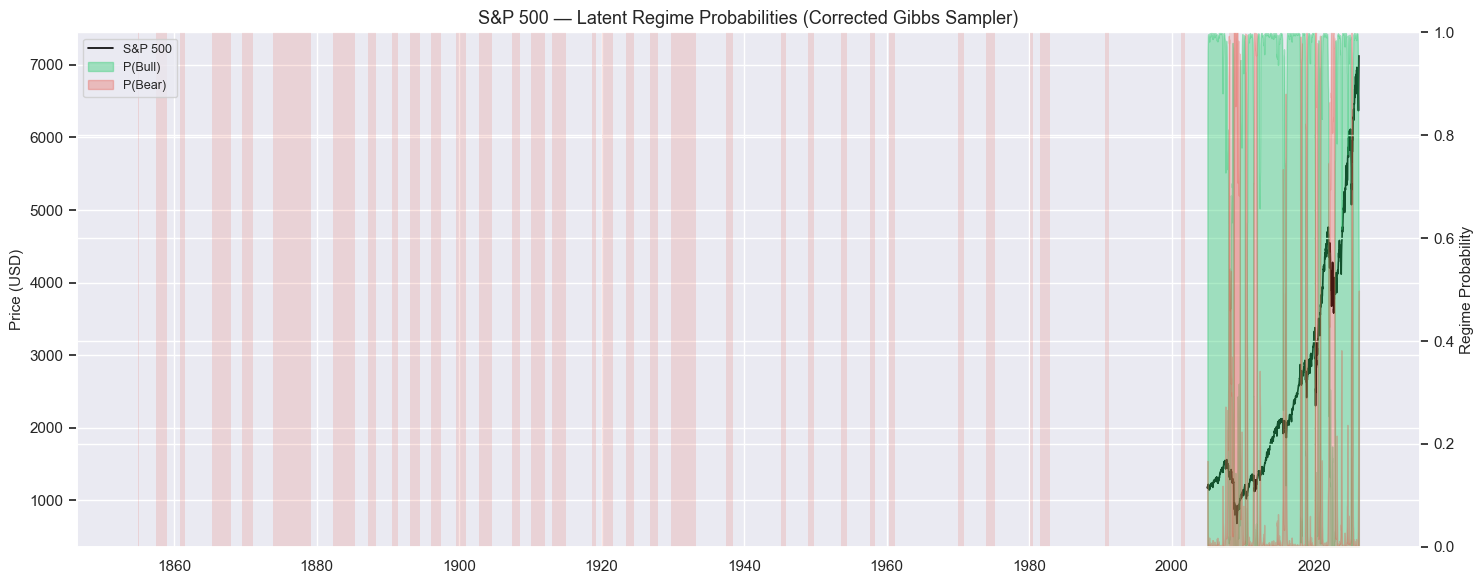

In [5]:
def shade_rec(ax, rec_df):
    mask = rec_df['USREC'] == 1
    in_rec, start = False, None
    for date, val in mask.items():
        if val and not in_rec:  start, in_rec = date, True
        elif not val and in_rec:
            ax.axvspan(start, date, color='#e74c3c', alpha=0.15, lw=0)
            in_rec = False
    if in_rec:
        ax.axvspan(start, rec_df.index[-1], color='#e74c3c', alpha=0.15, lw=0)

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(dates_sp, sp500_df['Close'], color='black', lw=1.2, label='S&P 500')
ax1.set_ylabel('Price (USD)', fontsize=11)

ax2 = ax1.twinx()
ax2.fill_between(dates_sp, 0, P_bull_sp,     color='#2ecc71', alpha=0.40, label='P(Bull)')
ax2.fill_between(dates_sp, 0, 1-P_bull_sp,   color='#e74c3c', alpha=0.30, label='P(Bear)')
ax2.set_ylim(0, 1); ax2.set_ylabel('Regime Probability', fontsize=11)
shade_rec(ax2, recession_df)

ax1.set_title('S&P 500 — Latent Regime Probabilities (Corrected Gibbs Sampler)', fontsize=13)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h1+h2, l1+l2, loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


## NIFTY 50 — Gibbs Sampling (Corrected)

=== NIFTY 50 Posterior Estimates ===
Bull  mu = +0.00241 | sigma2 = 0.000398
Bear  mu = -0.00247 | sigma2 = 0.002795
Bear/Bull variance ratio = 7.02x


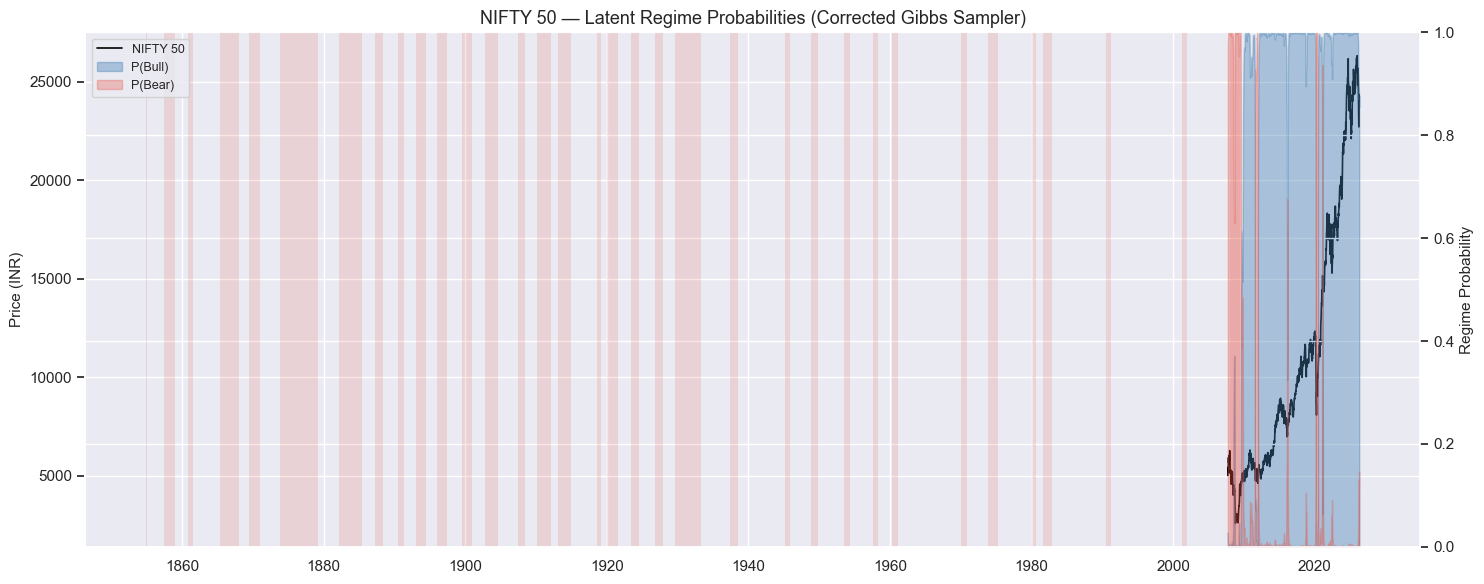

In [6]:
y_nif    = nifty50_df['Log_Return'].values
dates_nif = nifty50_df.index

np.random.seed(42)
res_nif = gibbs_msm(y_nif, n_iter=3000, burn_in=1000)

S_mat_nif  = np.array(res_nif['S'])
P_bull_nif = S_mat_nif.mean(axis=0)

mu_post_nif   = np.array(res_nif['mu']).mean(axis=0)
sig2_post_nif = np.array(res_nif['sigma2']).mean(axis=0)
if sig2_post_nif[0] > sig2_post_nif[1]:
    bull_idx_n, bear_idx_n = 1, 0
else:
    bull_idx_n, bear_idx_n = 0, 1
    P_bull_nif = 1 - P_bull_nif

print("=== NIFTY 50 Posterior Estimates ===")
print(f"Bull  mu = {mu_post_nif[bull_idx_n]:+.5f} | sigma2 = {sig2_post_nif[bull_idx_n]:.6f}")
print(f"Bear  mu = {mu_post_nif[bear_idx_n]:+.5f} | sigma2 = {sig2_post_nif[bear_idx_n]:.6f}")
print(f"Bear/Bull variance ratio = {sig2_post_nif[bear_idx_n]/sig2_post_nif[bull_idx_n]:.2f}x")

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(dates_nif, nifty50_df['Close'], color='black', lw=1.2, label='NIFTY 50')
ax1.set_ylabel('Price (INR)', fontsize=11)
ax2 = ax1.twinx()
ax2.fill_between(dates_nif, 0, P_bull_nif,   color='steelblue', alpha=0.40, label='P(Bull)')
ax2.fill_between(dates_nif, 0, 1-P_bull_nif, color='#e74c3c',   alpha=0.30, label='P(Bear)')
ax2.set_ylim(0, 1); ax2.set_ylabel('Regime Probability', fontsize=11)
shade_rec(ax2, recession_df)
ax1.set_title('NIFTY 50 — Latent Regime Probabilities (Corrected Gibbs Sampler)', fontsize=13)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h1+h2, l1+l2, loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


## Convergence Diagnostics — S&P 500

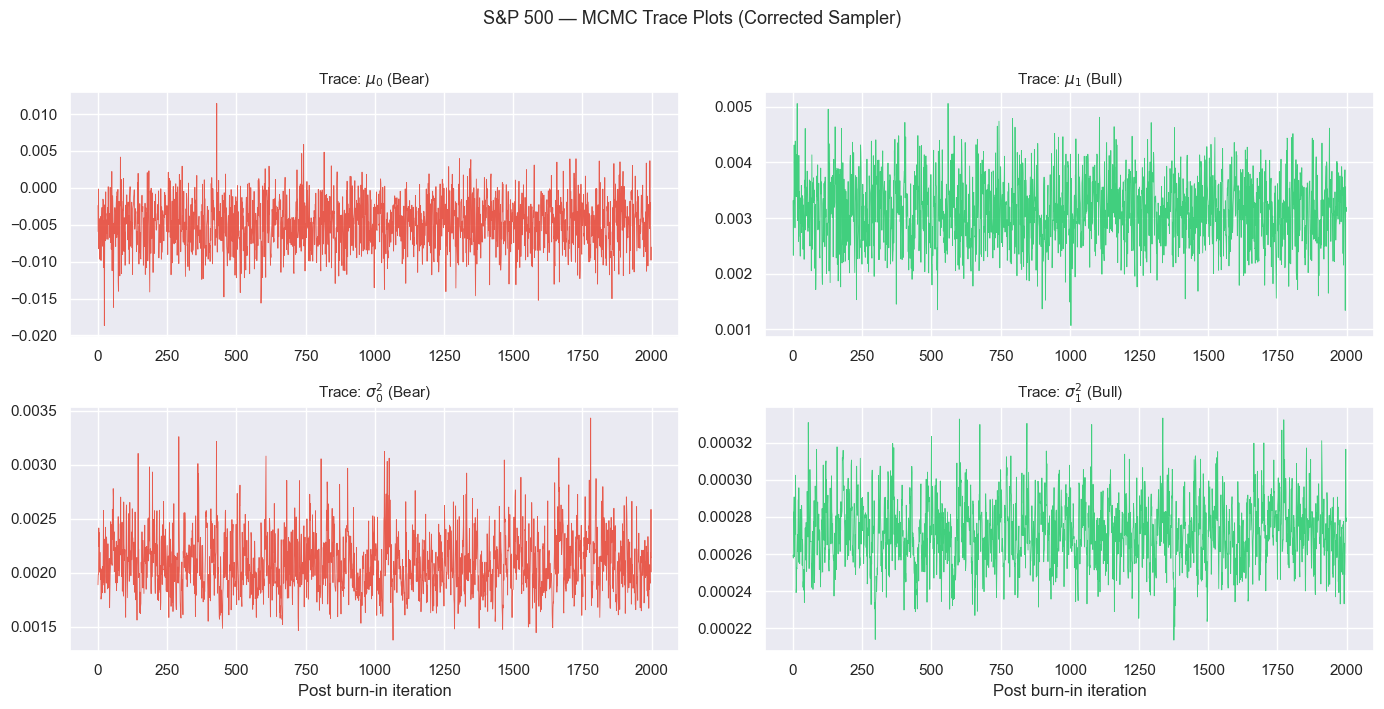

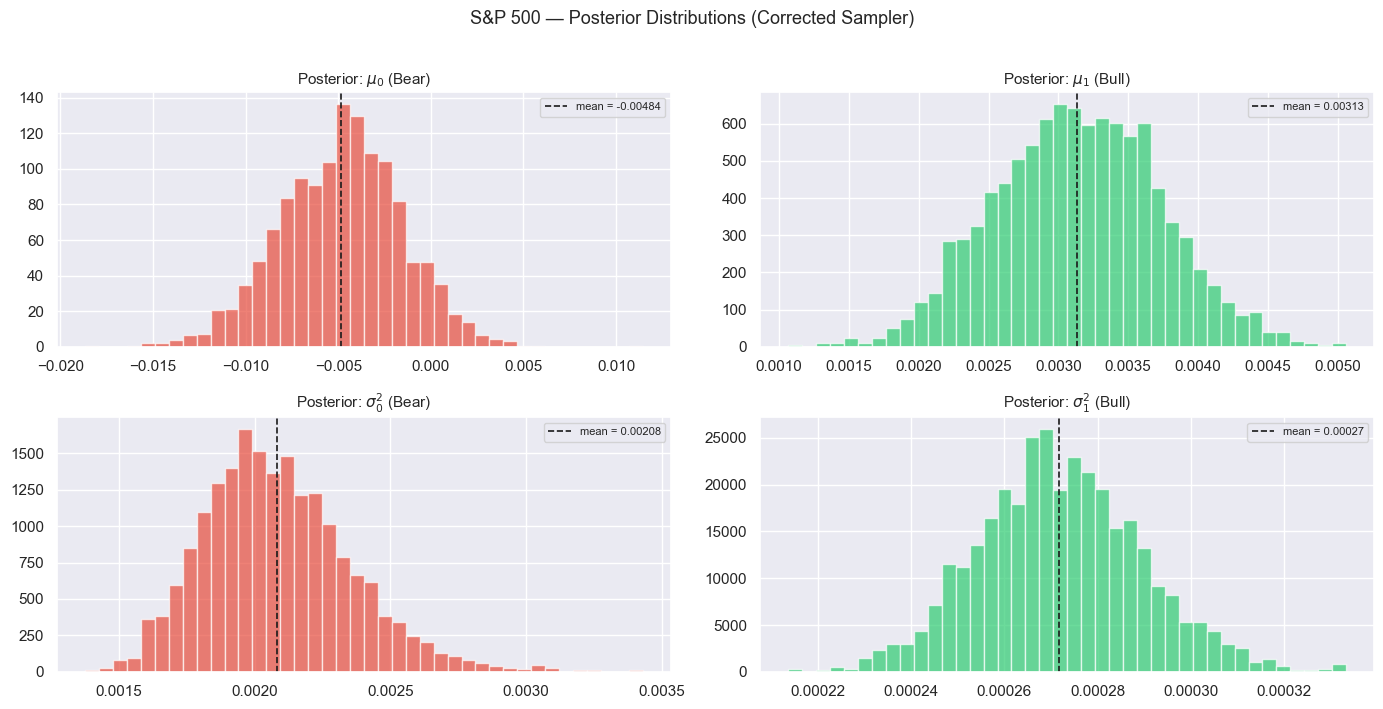

In [7]:
mu_arr   = np.array(res_sp['mu'])
sig2_arr = np.array(res_sp['sigma2'])
p_arr    = np.array(res_sp['p'])

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes[0,0].plot(mu_arr[:,0],   lw=0.6, color='#e74c3c', alpha=0.9)
axes[0,0].set_title('Trace: $\mu_0$ (Bear)', fontsize=11)
axes[0,1].plot(mu_arr[:,1],   lw=0.6, color='#2ecc71', alpha=0.9)
axes[0,1].set_title('Trace: $\mu_1$ (Bull)', fontsize=11)
axes[1,0].plot(sig2_arr[:,0], lw=0.6, color='#e74c3c', alpha=0.9)
axes[1,0].set_title('Trace: $\sigma^2_0$ (Bear)', fontsize=11); axes[1,0].set_xlabel('Post burn-in iteration')
axes[1,1].plot(sig2_arr[:,1], lw=0.6, color='#2ecc71', alpha=0.9)
axes[1,1].set_title('Trace: $\sigma^2_1$ (Bull)', fontsize=11); axes[1,1].set_xlabel('Post burn-in iteration')
plt.suptitle('S&P 500 — MCMC Trace Plots (Corrected Sampler)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, samples, title, c in [
        (axes[0,0], mu_arr[:,0],   '$\mu_0$ (Bear)',       '#e74c3c'),
        (axes[0,1], mu_arr[:,1],   '$\mu_1$ (Bull)',       '#2ecc71'),
        (axes[1,0], sig2_arr[:,0], '$\sigma^2_0$ (Bear)',  '#e74c3c'),
        (axes[1,1], sig2_arr[:,1], '$\sigma^2_1$ (Bull)',  '#2ecc71')]:
    ax.hist(samples, bins=40, color=c, alpha=0.7, density=True, edgecolor='white')
    ax.axvline(samples.mean(), color='k', lw=1.2, ls='--',
               label=f'mean = {samples.mean():.5f}')
    ax.set_title(f'Posterior: {title}', fontsize=11); ax.legend(fontsize=8)
plt.suptitle('S&P 500 — Posterior Distributions (Corrected Sampler)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## What the Fix Changes

The corrected sampler now explores the full joint posterior
$p(\mu, \sigma^2, \mathbf{p}, \mathbf{S} \mid \mathbf{y})$.

| | Old (broken) | New (fixed) |
|--|--|--|
| **States updated?** | Never — stuck at `(y ≥ median)` | Every iteration via FFBS |
| **μ, σ² conditioned on** | Static median-split | Evolving posterior states |
| **Posterior valid?** | No — wrong conditional | Yes — true joint posterior |
| **Trace plots look fine?** | Yes (that's why it's dangerous) | Yes |
